Name: Manas Tiwari  
GitHub Username: mt431  
USC ID: 5446032746


# Homework 2


## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Imports


In [15]:
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")
alpha = 0.05  # Significance cutoff.


In [16]:
data = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
predictors = data.columns.drop("PE").tolist()
data.head()


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. Rows and columns


In [17]:
print("Columns:", data.columns.tolist())
print(f"Rows: {data.shape[0]}; Columns: {data.shape[1]}")


Columns: ['AT', 'V', 'AP', 'RH', 'PE']
Rows: 9568; Columns: 5


Each row records hourly average conditions at full load. AT is temperature (°C), V is exhaust vacuum (cm Hg), AP is pressure (millibar), RH is humidity (%), and PE is electrical power output (MW).


#### ii. Pairwise scatterplots of all variables


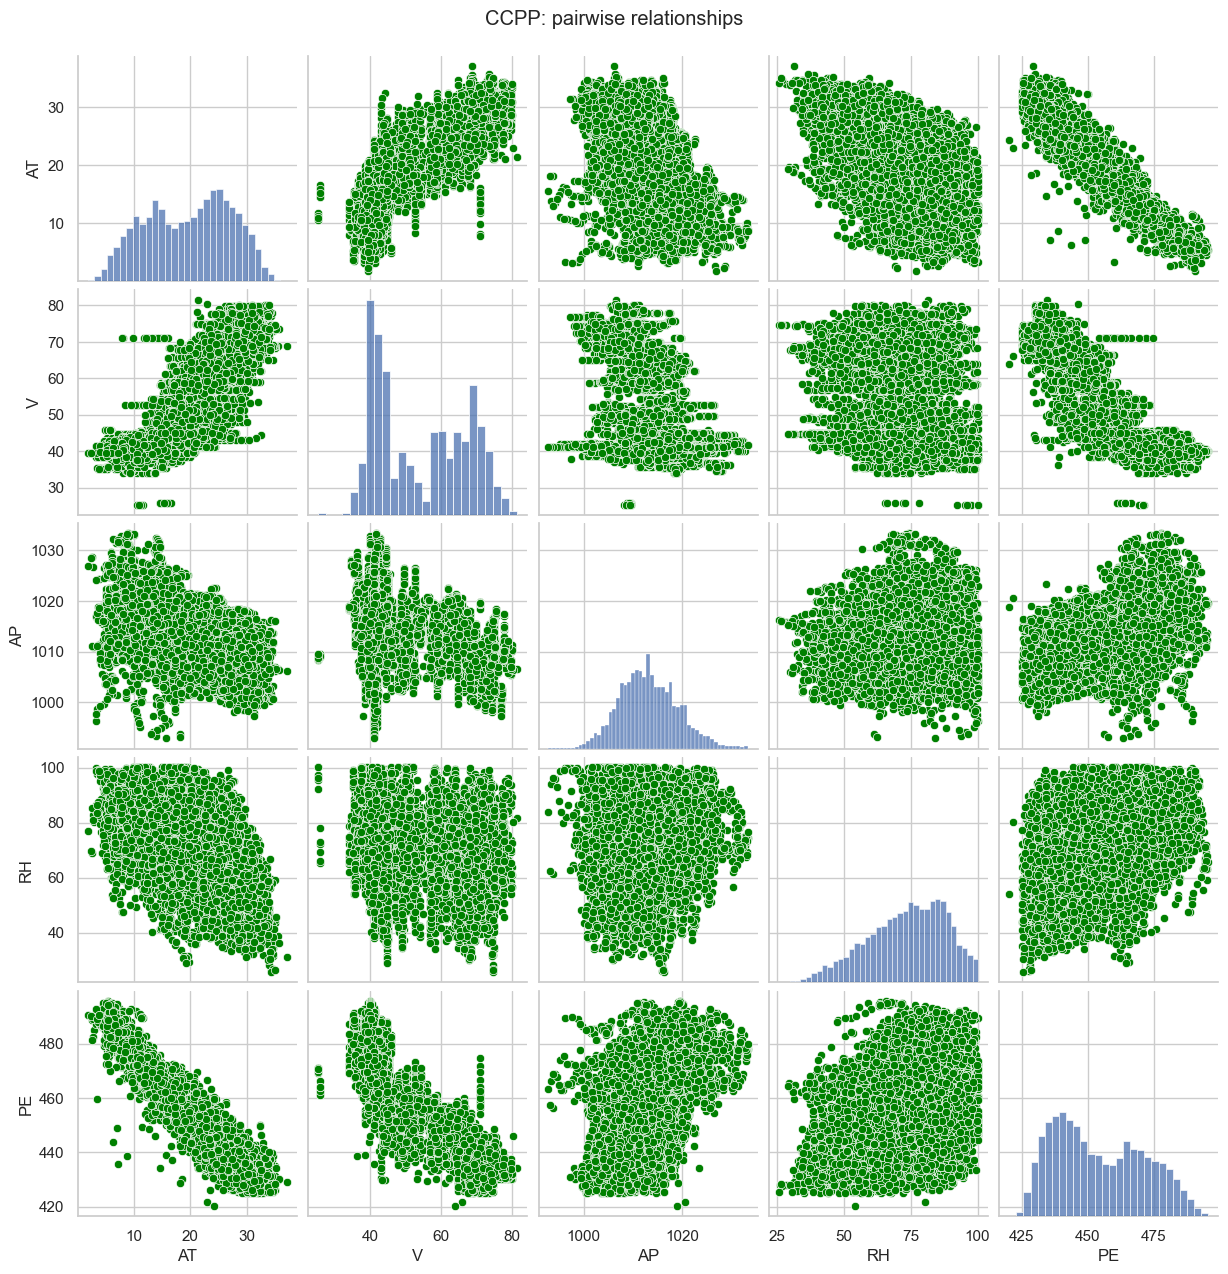

In [18]:
grid = sns.pairplot(data, plot_kws={"color": "green"})
grid.fig.suptitle("CCPP: pairwise relationships", y=1.02)
plt.show()


PE decreases strongly with AT and V. Its relationship with AP and RH are much weaker.

#### iii. Summary statistics


In [19]:
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
summary = pd.DataFrame({
    "Mean": data.mean(), "Median": data.median(),
    "Range": data.max() - data.min(), "Q1": q1, "Q3": q3, "IQR": q3 - q1
})
display(summary)


,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

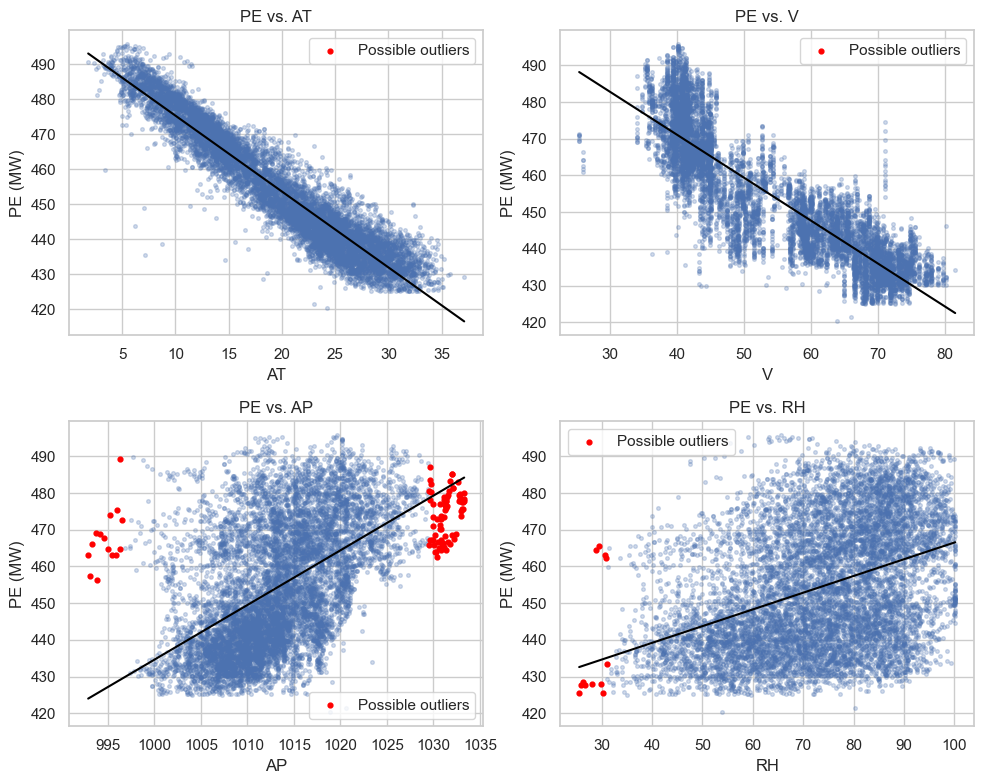

,Predictor,Intercept,Slope,p-value,Outliers
0,AT,497.034120,-2.171320,0.0,0
1,V,517.801526,-1.168135,0.0,0
2,AP,-1055.260989,1.489872,0.0,88
3,RH,420.961766,0.455650,0.0,12


In [20]:
simple_models = {}
simple_results = []
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for x, ax in zip(predictors, axes.flat):
    model = smf.ols(f"PE ~ {x}", data=data).fit()
    simple_models[x] = model
    iqr = q3[x] - q1[x]
    lower_bound = q1[x] - 1.5 * iqr
    upper_bound = q3[x] + 1.5 * iqr
    outliers = (data[x] < lower_bound) | (data[x] > upper_bound)
    simple_results.append([
        x, model.params["Intercept"], model.params[x],
        model.pvalues[x], outliers.sum()
    ])
    ax.scatter(data[x], data.PE, s=7, alpha=0.25)
    ax.scatter(
        data.loc[outliers, x], data.loc[outliers, "PE"],
        s=12, color="red", label="Possible outliers"
    )
    x_line = np.array([data[x].min(), data[x].max()])
    fitted_line = model.params["Intercept"] + model.params[x] * x_line
    ax.plot(x_line, fitted_line, color="black")
    ax.set(xlabel=x, ylabel="PE (MW)", title=f"PE vs. {x}")
    ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(
    simple_results,
    columns=["Predictor", "Intercept", "Slope", "p-value", "Outliers"]
))


All four slope p-values are below 0.05, so each predictor has a significant association with PE. AT and V show negative correlation while AP and RH have a weaker positive correlation.

For each predictor, values below Q_1 - 1.5IQR or above Q_3 + 1.5IQR are flagged as outliers. No outliers were removed.


### (d) Multiple Regression

In [21]:
linear_formula = "PE ~ " + " + ".join(predictors)
multiple_model = smf.ols(linear_formula, data=data).fit()
display(pd.DataFrame({
    "Coefficient": multiple_model.params,
    "p-value": multiple_model.pvalues
}))


,Coefficient,p-value
Intercept,454.609274,0.000000e+00
AT,-1.977513,0.000000e+00
V,-0.233916,4.375305e-215
AP,0.062083,5.507109e-11
RH,-0.158054,3.104584e-293


We can safely reject H0, beta_j=0 for all four predictors since all of their p values are less than 0.05


### (e) Compare Simple and Multiple Regression


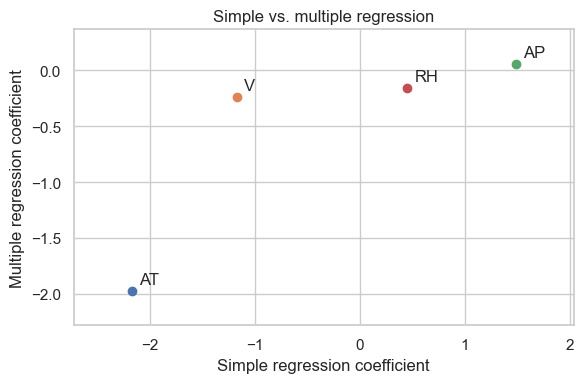

In [22]:
plt.figure(figsize=(6, 4))
for x in predictors:
    simple_slope = simple_models[x].params[x]
    multiple_slope = multiple_model.params[x]
    plt.scatter(simple_slope, multiple_slope)
    plt.annotate(
        x, (simple_slope, multiple_slope),
        xytext=(5, 5), textcoords="offset points"
    )
plt.xlabel("Simple regression coefficient")
plt.ylabel("Multiple regression coefficient")
plt.title("Simple vs. multiple regression")
plt.margins(0.15)
plt.tight_layout()
plt.show()


V and AP move closer to zero, AT stays negative, and RH changes from positive to negative. Multiple regression seems to adjust for the other correlated predictors, unlike the simple regression


### (f) Evidence of Nonlinear Association

In [23]:
cubic_results = []
for x in predictors:
    formula = f"PE ~ {x} + I({x} ** 2) + I({x} ** 3)"
    model = smf.ols(formula, data=data).fit(method="qr")
    cubic_results.append([
        x, model.pvalues[f"I({x} ** 2)"], model.pvalues[f"I({x} ** 3)"]
    ])
display(pd.DataFrame(
    cubic_results, columns=["Predictor", "p(X²)", "p(X³)"]
))


,Predictor,p(X²),p(X³)
0,AT,8.833045e-73,3.652185e-110
1,V,7.684969e-01,1.373489e-02
2,AP,6.955015e-67,1.172404e-66
3,RH,9.395430e-06,1.440279e-05


The cubic term is significant for all four predictors, showing evidence of nonlinearity. The quadratic term is also significant for AT, AP, and RH, but not for V.


### (g) Interactions of Predictors

In [24]:
interaction_terms = [f"{a}:{b}" for a, b in combinations(predictors, 2)]
interaction_model = smf.ols(
    "PE ~ " + " + ".join(predictors + interaction_terms), data=data
).fit()
display(pd.DataFrame({
    "Coefficient": interaction_model.params,
    "p-value": interaction_model.pvalues
}))


,Coefficient,p-value
Intercept,685.782468,3.231607e-18
AT,-4.347014,6.701873e-02
V,-7.674858,1.371251e-08
AP,-0.152355,4.735732e-02
RH,1.570907,4.225213e-02
AT:V,0.020971,3.333358e-117
AT:AP,0.001759,4.520509e-01
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
V:RH,0.000839,8.619366e-02


AT:V, AT:RH, V:AP, and AP:RH are significant. AT:AP and V:RH are not. Hence, we can conclude that some predictors effects depend on the values of other predictors.


### (h) Improvement

Use a 70/30 split with seed 42 for reproducable results. All terms through degree 4 are initially included, removing terms greater than 0.05. 
Some polynomial values reach extremely high values. Some columns are scaled before fitting as per ChatGPT's suggestion

In [25]:
train, test = train_test_split(data, train_size=0.70, random_state=42)
print(f"Training observations: {len(train)}; test observations: {len(test)}")
baseline = smf.ols(linear_formula, data=train).fit()

poly = PolynomialFeatures(degree=4)
train_values = poly.fit_transform(train[predictors])
test_values = poly.transform(test[predictors])
feature_names = poly.get_feature_names_out(predictors)
train_poly = pd.DataFrame(train_values, columns=feature_names, index=train.index)
test_poly = pd.DataFrame(test_values, columns=feature_names, index=test.index)

# Use training scales for both sets.
feature_scale = train_poly.abs().max()
train_poly = train_poly / feature_scale
test_poly = test_poly / feature_scale
full_model = sm.OLS(train.PE, train_poly).fit()
print("Starting terms, including intercept:", len(feature_names))

powers = pd.DataFrame(poly.powers_, index=feature_names)
terms = feature_names.tolist()
elimination = []
while True:
    reduced = sm.OLS(train.PE, train_poly[terms]).fit()
    removable = []
    for term in terms[1:]:
        # Keep a term if a higher-order term still uses it.
        contains_term = (powers.loc[terms] >= powers.loc[term]).all(axis=1)
        if contains_term.sum() == 1:
            removable.append(term)
    pvalues = reduced.pvalues[removable]
    if pvalues.empty or pvalues.max() < alpha:
        break
    worst = pvalues.idxmax()
    elimination.append({"Removed term": worst, "p-value at removal": pvalues[worst]})
    terms.remove(worst)

display(pd.DataFrame(elimination))
print("Removed terms:", len(elimination))
print("Remaining terms, including intercept:", len(terms))
display(pd.DataFrame({
    "Coefficient (original units)": reduced.params / feature_scale[terms],
    "p-value": reduced.pvalues
}))
print("Insignificant terms kept for hierarchy:")
display(reduced.pvalues[reduced.pvalues >= alpha])

regression_errors = pd.DataFrame({
    "Linear": [
        mean_squared_error(train.PE, baseline.predict(train)),
        mean_squared_error(test.PE, baseline.predict(test))
    ],
    "Full degree 4 (before removal)": [
        mean_squared_error(train.PE, full_model.predict(train_poly)),
        mean_squared_error(test.PE, full_model.predict(test_poly))
    ],
    "Reduced degree 4 (after removal)": [
        mean_squared_error(train.PE, reduced.predict(train_poly[terms])),
        mean_squared_error(test.PE, reduced.predict(test_poly[terms]))
    ]
}, index=["Train MSE", "Test MSE"]).T
display(regression_errors)


Training observations: 6697; test observations: 2871
Starting terms, including intercept: 70


,Removed term,p-value at removal
0,AT^2 V RH,0.967940
1,V^4,0.922392
2,AT^2 AP RH,0.800034
3,V^2 AP RH,0.847238
4,RH^4,0.768259
5,AT AP^3,0.713864
6,V^3 RH,0.732040
7,AT^3 RH,0.599830
8,AT V^2 AP,0.641432
9,AT^2 RH^2,0.628559


Removed terms: 19
Remaining terms, including intercept: 51


,Coefficient (original units),p-value
1,4.978962e+07,7.110023e-05
AT,1.351214e+04,2.272600e-06
V,-6.279989e+03,3.390175e-03
AP,-1.934462e+05,8.102915e-05
RH,-3.003319e+04,1.968600e-02
AT^2,-2.774249e+02,6.635993e-08
AT V,-2.563364e+01,1.877341e-10
AT AP,-2.574885e+01,3.719760e-06
AT RH,-8.879794e+01,7.359784e-05
V^2,7.136128e+01,2.934350e-04


Insignificant terms kept for hierarchy:


RH^2       0.146865
AT^3       0.920493
AT V^2     0.342010
V^2 RH     0.185461
AP RH^2    0.070509
dtype: float64

,Train MSE,Test MSE
Linear,20.580840,21.239857
Full degree 4 (before removal),16.497220,17.216454
Reduced degree 4 (after removal),16.530754,17.210871


Both degree-4 models improve on the linear model. Pruning raises training MSE slightly and lowers test MSE slightly on this split. Some terms with p-values above 0.05 stay because retained higher-order terms require them.


### (i) KNN Regression

#### i. Raw and min–max normalized features
Min–max scaling used since nothing was explcitly mentioned


Raw best k values: [5] ; selected: 5
Min–max best k values: [4] ; selected: 4


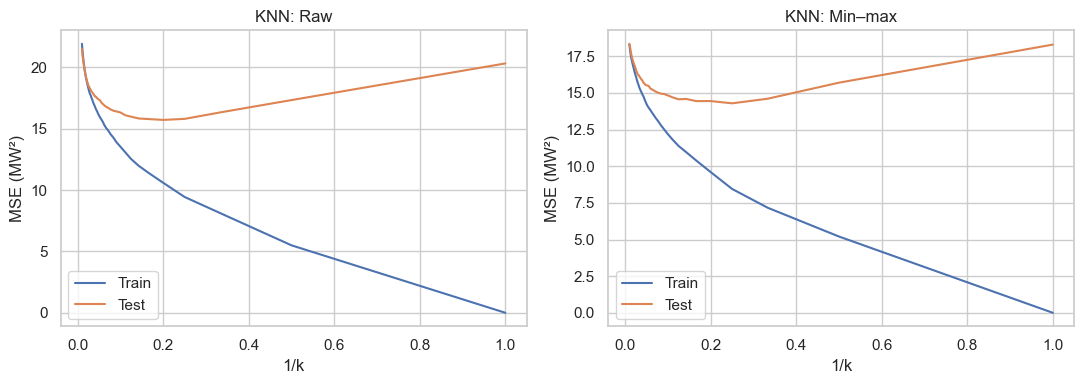

,Best k,Train MSE,Test MSE
Model,,,
KNN (Raw),5,10.600769,15.726820
KNN (Min–max),4,8.454348,14.291333


In [26]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(train[predictors])
x_test_scaled = scaler.transform(test[predictors])
feature_sets = {
    "Raw": (train[predictors], test[predictors]),
    "Min–max": (x_train_scaled, x_test_scaled)
}
knn_best = []
k_values = np.arange(1, 101)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, name in enumerate(feature_sets):
    x_train, x_test = feature_sets[name]
    train_errors, test_errors = [], []
    for k in k_values:
        model = KNeighborsRegressor(n_neighbors=k, metric="euclidean")
        model.fit(x_train, train.PE)
        train_errors.append(mean_squared_error(train.PE, model.predict(x_train)))
        test_errors.append(mean_squared_error(test.PE, model.predict(x_test)))
    tied = k_values[np.isclose(test_errors, min(test_errors), rtol=1e-12, atol=1e-12)]
    best_k = tied[0]
    print(name, "best k values:", tied.tolist(), "; selected:", best_k)
    knn_best.append([
        f"KNN ({name})", best_k,
        train_errors[best_k - 1], test_errors[best_k - 1]
    ])
    axes[i].plot(1 / k_values, train_errors, label="Train")
    axes[i].plot(1 / k_values, test_errors, label="Test")
    axes[i].set(xlabel="1/k", ylabel="MSE (MW²)", title=f"KNN: {name}")
    axes[i].legend()
plt.tight_layout()
plt.show()
knn_results = pd.DataFrame(
    knn_best, columns=["Model", "Best k", "Train MSE", "Test MSE"]
).set_index("Model")
display(knn_results)


Small k overfits, while very large k oversmooths. Min–max scaling gives the lower minimum test MSE.


### (j) Compare KNN and Linear Regression


In [27]:
best_regression = regression_errors.loc[
    regression_errors["Test MSE"] == regression_errors["Test MSE"].min()]
comparison = pd.concat([best_regression, knn_results[["Train MSE", "Test MSE"]]])
display(comparison.sort_values("Test MSE"))


,Train MSE,Test MSE
KNN (Min–max),8.454348,14.291333
KNN (Raw),10.600769,15.726820
Reduced degree 4 (after removal),16.530754,17.210871


Min–max KNN performs best, followed by raw KNN and the reduced degree-4 model. KNN captures local patterns but has a larger train–test error gap. These errors use the same split; selecting $k$ on the test set makes its minimum optimistic.


## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Since there are many observations and few predictors, a flexible model would be able to learn complex patterns without while an inflexible model may struggle to learn the complexities without introducing bias/ high variance. Hence, the flexible method should be better. 


### (b) The number of predictors p is extremely large, and the number of observations n is small.

With many predictors and few observations, a flexible method is more likely to overfit as compared to an inflexible model. Hence, the flexible model will perform worse.


### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would be more likely to capture the nonlinear relationship and reduce bias as compared to the inflexible model. Hence, it should perform better.


### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

The high noise content makes a flexible method more likely to fit random variation. The inflexible model should ideally be able to learn the core trend and be more insensitive to the noise present. Neither method would be able to fully remove irreducible error.


## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distances for point X(0,0,0) from the observations are -

1. sqrt( (0 - 0)<sup>2</sup> + ( 0 - 3)<sup>2</sup> + (0 - 0)<sup>2</sup>) = 3
2. sqrt( (0 - 2)<sup>2</sup> + ( 0 - 0)<sup>2</sup> + (0 - 0)<sup>2</sup>) = 2
3. sqrt( (0 - 0)<sup>2</sup> + ( 0 - 1)<sup>2</sup> + (0 - 3)<sup>2</sup>) = 3.162
4. sqrt( (0 - 0)<sup>2</sup> + ( 0 - 1)<sup>2</sup> + (0 - 2)<sup>2</sup>) = 2.236
5. sqrt( (0 - (-1))<sup>2</sup>  +   (0-0)<sup>2</sup> +   (0-1)<sup>2</sup>) = 1.414
6. sqrt( (0 - 1)<sup>2</sup> + ( 0 - 0)<sup>2</sup> + (0 - 0)<sup>2</sup>) = 1.732



### (b) What is our prediction with K = 1? Why?

If we keep k as 1, we will only consider a single point to make our classification decision. With only a single point as reference, the closest point would be the 5th one, and the model will classify it as green


### (c) What is our prediction with K = 3? Why?

If we keep k=3, then we'll consider 3 points at once to make our classification decision. Hence based on that the closest 3 points are 2nd(2,0,0), 5th(-1,0,1) and 6th(1,1,1). The 2nd point is Red, 5th point is Green and 6th point is Red. Therefore we'll classify the point X(0,0,0) as Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

A small k gives a flexible boundary that can follow the nonlinear Bayes boundary. A large K may oversmooth it.


## References

1. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
2. https://www.geeksforgeeks.org/non-linear-regression-examples-ml/
3. https://numustafa.medium.com/basics-of-machine-learning-understanding-bayesian-decision-theory-eb54ed405
4. ChatGPT assistance for certain sections of the notebook:
   
   How do I read data from a spreadsheet?
   The assignment specifies that I should find potential outliers but doesn't specify the algorithm I should use to detect them. What algorithms should I consider?
   What is the difference between z-score and IQR?
   What types of normalization should I use? 
   What is the difference between standard scaler and min max scaler? Which one would be more appropriate for this problem?
   What degree of terms should I check up to? It is not specified in the question?